In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ncr_land = pd.read_csv("..//pop_estimates//ncr_landarea_based.csv")
ncr_bldg = pd.read_csv("..//pop_estimates//ncr_building_based.csv")
ncr_bldg_fi = pd.read_csv("..//pop_estimates//ncr_building_based_filtered.csv")

rzl_land = pd.read_csv("..//pop_estimates//rizal_landarea_based.csv")
rzl_bldg = pd.read_csv("..//pop_estimates//rizal_building_based.csv")

In [3]:
ncr_pop = ncr_land.merge(ncr_bldg[["ADM4_PCODE","pop_est"]],how="left",on="ADM4_PCODE",suffixes=("_land","_bldg"))\
            .merge(ncr_bldg_fi[["ADM4_PCODE","pop_est"]],how="left",on="ADM4_PCODE")
ncr_pop.rename(columns={"pop_est":"pop_est_bldgfi"},inplace=True)

In [4]:
def rmse(arr1,arr2):
    return np.sqrt(np.mean((arr1-arr2)**2))
def mae(arr1,arr2):
    return np.mean(np.abs(arr1-arr2))
    
print("Root Mean Square Error")
print("Land area-based:\t\t",rmse(ncr_pop["pop"],ncr_pop["pop_est_land"]))
print("Building-based:\t\t\t",rmse(ncr_pop["pop"],ncr_pop["pop_est_bldg"]))
print("Building-based (filtered):\t",rmse(ncr_pop["pop"],ncr_pop["pop_est_bldgfi"]))

print("Mean Absolute Error")
print("Land area-based:\t\t",mae(ncr_pop["pop"],ncr_pop["pop_est_land"]))
print("Building-based:\t\t\t",mae(ncr_pop["pop"],ncr_pop["pop_est_bldg"]))
print("Building-based (filtered):\t",mae(ncr_pop["pop"],ncr_pop["pop_est_bldgfi"]))

Root Mean Square Error
Land area-based:		 16232.458454525908
Building-based:			 8883.512928479033
Building-based (filtered):	 7438.107848970685
Mean Absolute Error
Land area-based:		 4515.868709832762
Building-based:			 3503.798003029541
Building-based (filtered):	 2929.4712508996845


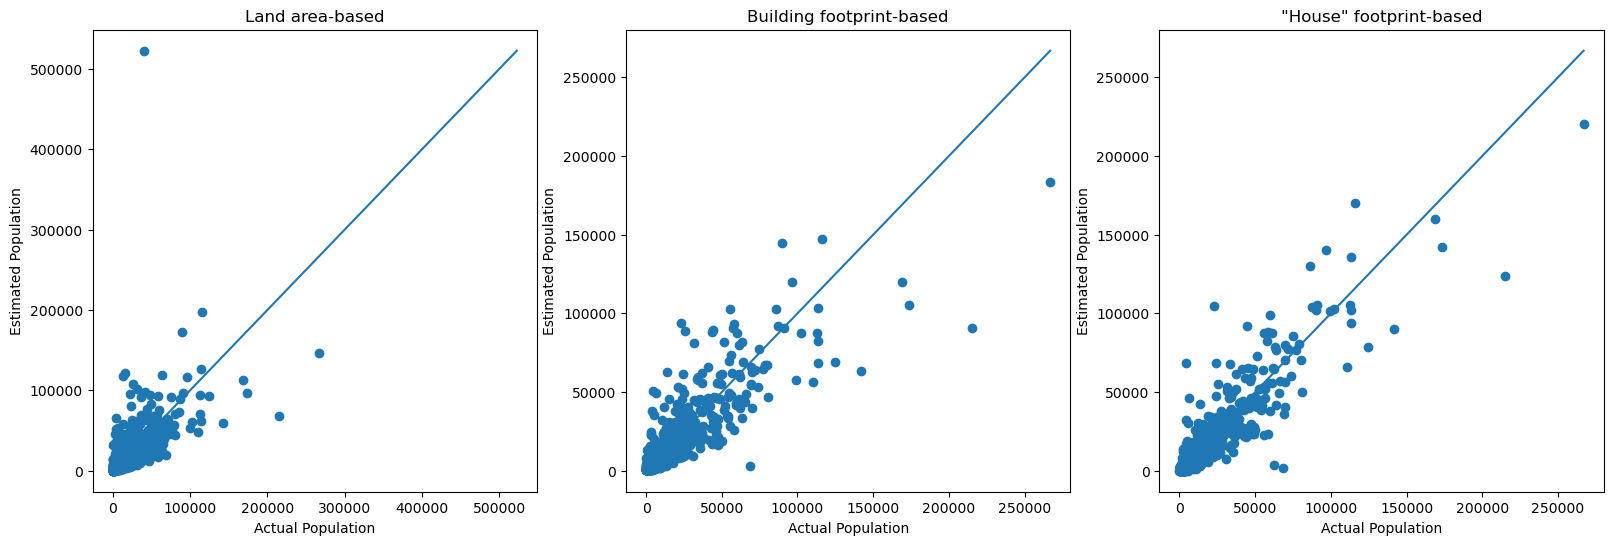

In [5]:
fig,ax = plt.subplots(1,3,figsize=(3*6.5,6))
col = "pop_est_land"
ax[0].set_title("Land area-based")
ax[0].scatter(ncr_pop["pop"],ncr_pop[col])
ax[0].plot([0,max(ncr_pop["pop"].max(),ncr_pop[col].max())],[0,max(ncr_pop["pop"].max(),ncr_pop[col].max())])
ax[0].set_xlabel("Actual Population")
ax[0].set_ylabel("Estimated Population")

col = "pop_est_bldg"
ax[1].set_title("Building footprint-based")
ax[1].scatter(ncr_pop["pop"],ncr_pop[col])
ax[1].plot([0,max(ncr_pop["pop"].max(),ncr_pop[col].max())],[0,max(ncr_pop["pop"].max(),ncr_pop[col].max())])
ax[1].set_xlabel("Actual Population")
ax[1].set_ylabel("Estimated Population")

col = "pop_est_bldgfi"
ax[2].set_title('"House" footprint-based')
ax[2].scatter(ncr_pop["pop"],ncr_pop[col])
ax[2].plot([0,max(ncr_pop["pop"].max(),ncr_pop[col].max())],[0,max(ncr_pop["pop"].max(),ncr_pop[col].max())])
ax[2].set_xlabel("Actual Population")
ax[2].set_ylabel("Estimated Population")

plt.show()

## Rizal

In [6]:
rzl_pop = rzl_land.merge(rzl_bldg[["ADM4_PCODE","pop_est"]],how="left",on="ADM4_PCODE",suffixes=("_land","_bldg"))

In [7]:
def rmse(arr1,arr2):
    return np.sqrt(np.mean((arr1-arr2)**2))
def mae(arr1,arr2):
    return np.mean(np.abs(arr1-arr2))
    
print("Root Mean Square Error")
print("Land area-based:\t\t",rmse(rzl_pop["pop"],rzl_pop["pop_est_land"]))
print("Building-based:\t\t\t",rmse(rzl_pop["pop"],rzl_pop["pop_est_bldg"]))

print("Mean Absolute Error")
print("Land area-based:\t\t",mae(rzl_pop["pop"],rzl_pop["pop_est_land"]))
print("Building-based:\t\t\t",mae(rzl_pop["pop"],rzl_pop["pop_est_bldg"]))

Root Mean Square Error
Land area-based:		 35836.95695823364
Building-based:			 7760.898006888479
Mean Absolute Error
Land area-based:		 13720.878604956248
Building-based:			 3579.0081704377744


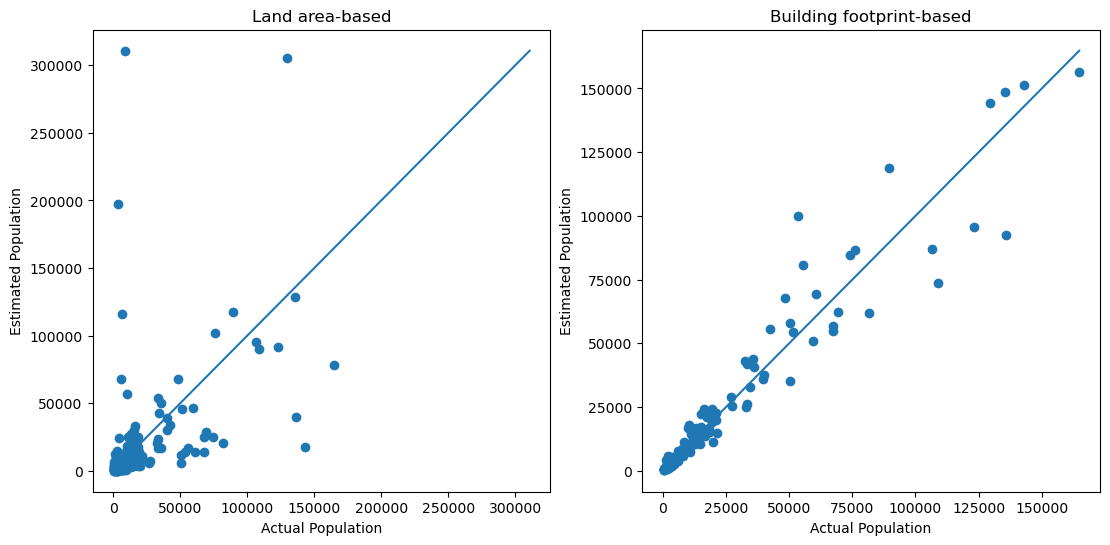

In [8]:
fig,ax = plt.subplots(1,2,figsize=(2*6.5,6))
col = "pop_est_land"
ax[0].set_title("Land area-based")
ax[0].scatter(rzl_pop["pop"],rzl_pop[col])
ax[0].plot([0,max(rzl_pop["pop"].max(),rzl_pop[col].max())],[0,max(rzl_pop["pop"].max(),rzl_pop[col].max())])
ax[0].set_xlabel("Actual Population")
ax[0].set_ylabel("Estimated Population")

col = "pop_est_bldg"
ax[1].set_title("Building footprint-based")
ax[1].scatter(rzl_pop["pop"],rzl_pop[col])
ax[1].plot([0,max(rzl_pop["pop"].max(),rzl_pop[col].max())],[0,max(rzl_pop["pop"].max(),rzl_pop[col].max())])
ax[1].set_xlabel("Actual Population")
ax[1].set_ylabel("Estimated Population")

plt.show()